# Image Denoising Using Autoencoder on MNIST

## Objective

The objective of this project is to build a Deep Learning model that can remove artificial noise from handwritten digit images using a Convolutional Denoising Autoencoder.

The project includes:

1. Loading and preprocessing the MNIST dataset.
2. Adding artificial Gaussian noise to the images.
3. Building a Convolutional Denoising Autoencoder.
4. Training the model using noisy images as input and clean images as targets.
5. Generating denoised images on the test dataset.
6. Comparing original, noisy, and denoised images.
7. Evaluating denoising performance using Mean Squared Error (MSE).
8. Performing an optional experiment with different noise levels.

# Importing Required Libraries

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from  torch.utils.data import DataLoader, SubsetRandomSampler
import torch.optim
from torchvision import datasets,transforms

## Step 1: Loading and Preprocessing the MNIST Dataset

In this step, I am loading the MNIST handwritten digit dataset using PyTorch. The images are converted into tensors using the ToTensor transformation so that they can be used as input to the neural network.

## Step 2: Splitting the Training Dataset into Training and Validation Sets

In this step, I am defining the validation split, batch size, number of workers, and other parameters required for preparing the training and validation datasets.

In [38]:
transform = transforms.ToTensor()


train_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

print("Training dataset size:", len(train_data))
print("Testing dataset size:", len(test_data))

Training dataset size: 60000
Testing dataset size: 10000


## Step 3: Splitting the Training Dataset into Training and Validation Sets

In [40]:
valid_size = 0.2
batch_size = 128


train_length = len(train_data)


indices = list(range(train_length))
np.random.shuffle(indices)


split = int(np.floor(valid_size * train_length))

train_idx = indices[split:]
valid_idx = indices[:split]


train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SubsetRandomSampler(valid_idx)


train_loader = DataLoader(
    train_data,
    batch_size=batch_size,
    sampler=train_sampler
)

valid_loader = DataLoader(
    train_data,
    batch_size=batch_size,
    sampler=valid_sampler
)

test_loader = DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(valid_loader))
print("Testing batches:", len(test_loader))

Training batches: 375
Validation batches: 94
Testing batches: 79


## Step 4: Visualizing Original MNIST Images

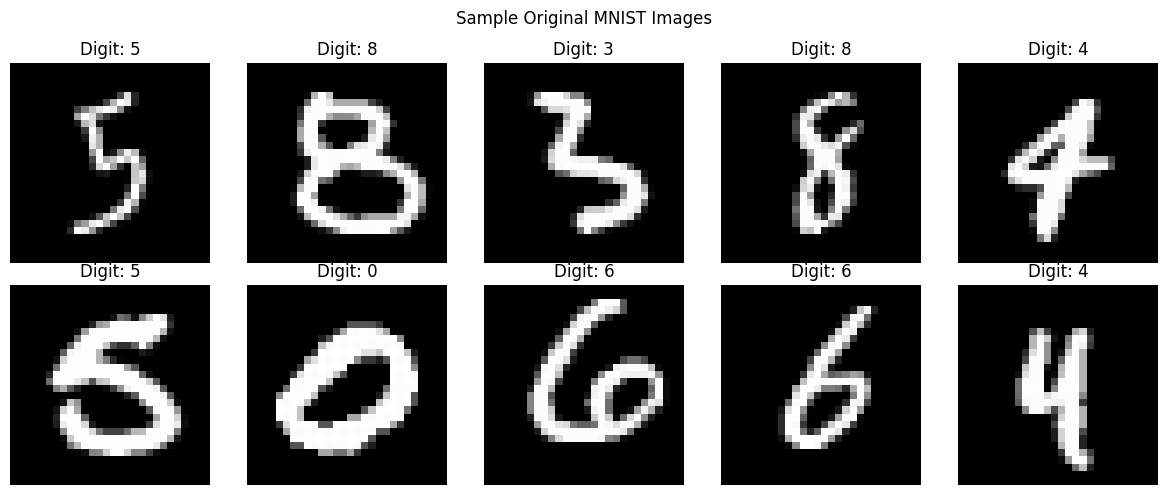

In [41]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(f"Digit: {labels[i].item()}")
    plt.axis("off")

plt.suptitle("Sample Original MNIST Images")
plt.tight_layout()
plt.show()

## Step 5: Adding Artificial Gaussian Noise

In [42]:
noise_factor = 0.3


def add_noise(images, noise_factor=0.3):


    noise = noise_factor * torch.randn_like(images)


    noisy_images = images + noise

    noisy_images = torch.clamp(
        noisy_images,
        0.0,
        1.0
    )

    return noisy_images

## Step 6: Creating Noisy Input Images

In [43]:
noisy_images = add_noise(
    images,
    noise_factor
)

print("Original image shape:", images.shape)
print("Noisy image shape:", noisy_images.shape)

Original image shape: torch.Size([128, 1, 28, 28])
Noisy image shape: torch.Size([128, 1, 28, 28])


## Step 7: Visualizing Original and Noisy Images

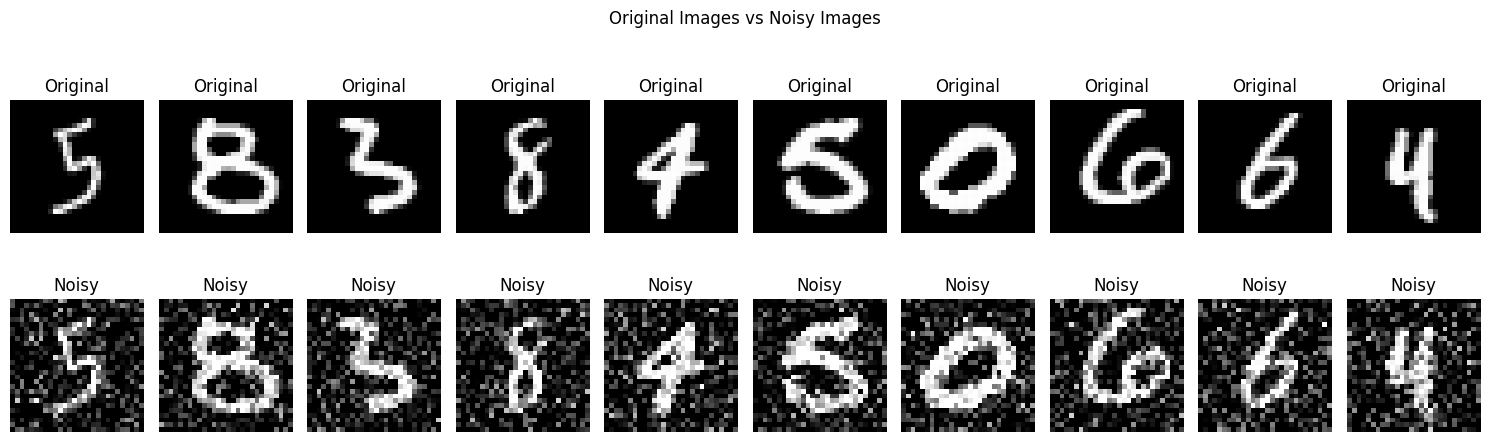

In [44]:
plt.figure(figsize=(15, 5))

for i in range(10):


    plt.subplot(2, 10, i + 1)
    plt.imshow(
        images[i].squeeze(),
        cmap="gray"
    )
    plt.title("Original")
    plt.axis("off")


    plt.subplot(2, 10, i + 11)
    plt.imshow(
        noisy_images[i].squeeze(),
        cmap="gray"
    )
    plt.title("Noisy")
    plt.axis("off")

plt.suptitle(
    "Original Images vs Noisy Images"
)

plt.tight_layout()
plt.show()

## Step 8: Building the Convolutional Denoising Autoencoder

In [46]:
class DenoisingAutoencoder(nn.Module):

    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()



        self.encoder = nn.Sequential(

            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            ),

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            )
        )



        self.decoder = nn.Sequential(

            nn.ConvTranspose2d(
                in_channels=64,
                out_channels=32,
                kernel_size=2,
                stride=2
            ),

            nn.ReLU(),

            nn.ConvTranspose2d(
                in_channels=32,
                out_channels=1,
                kernel_size=2,
                stride=2
            ),

            nn.Sigmoid()
        )

    def forward(self, x):


        encoded = self.encoder(x)


        decoded = self.decoder(encoded)

        return decoded

## Step 9: Creating and Inspecting the Autoencoder Model

In [47]:
model = DenoisingAutoencoder()


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


model = model.to(device)

print("Using device:", device)

print("\nModel Architecture:")
print(model)

Using device: cpu

Model Architecture:
DenoisingAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(32, 1, kernel_size=(2, 2), stride=(2, 2))
    (3): Sigmoid()
  )
)


## Step 10: Defining Loss Function and Optimizer

In [49]:
criterion = nn.MSELoss()


optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss Function: Mean Squared Error (MSE)")
print("Optimizer: Adam")
print("Learning Rate: 0.001")

Loss Function: Mean Squared Error (MSE)
Optimizer: Adam
Learning Rate: 0.001


## Step 11: Training the Denoising Autoencoder

In [50]:
num_epochs = 20

train_losses = []
valid_losses = []

for epoch in range(num_epochs):


    model.train()

    running_train_loss = 0.0

    for clean_images, _ in train_loader:

        clean_images = clean_images.to(device)


        noisy_images = add_noise(
            clean_images,
            noise_factor
        )


        optimizer.zero_grad()


        reconstructed_images = model(
            noisy_images
        )


        loss = criterion(
            reconstructed_images,
            clean_images
        )


        loss.backward()


        optimizer.step()

        running_train_loss += loss.item()


    train_loss = (
        running_train_loss
        / len(train_loader)
    )



    model.eval()

    running_valid_loss = 0.0

    with torch.no_grad():

        for clean_images, _ in valid_loader:

            clean_images = clean_images.to(device)


            noisy_images = add_noise(
                clean_images,
                noise_factor
            )


            reconstructed_images = model(
                noisy_images
            )


            loss = criterion(
                reconstructed_images,
                clean_images
            )

            running_valid_loss += loss.item()

    valid_loss = (
        running_valid_loss
        / len(valid_loader)
    )

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] | "
        f"Training Loss: {train_loss:.4f} | "
        f"Validation Loss: {valid_loss:.4f}"
    )

Epoch [1/20] | Training Loss: 0.0526 | Validation Loss: 0.0118
Epoch [2/20] | Training Loss: 0.0102 | Validation Loss: 0.0092
Epoch [3/20] | Training Loss: 0.0087 | Validation Loss: 0.0083
Epoch [4/20] | Training Loss: 0.0080 | Validation Loss: 0.0078
Epoch [5/20] | Training Loss: 0.0077 | Validation Loss: 0.0076
Epoch [6/20] | Training Loss: 0.0074 | Validation Loss: 0.0073
Epoch [7/20] | Training Loss: 0.0072 | Validation Loss: 0.0072
Epoch [8/20] | Training Loss: 0.0071 | Validation Loss: 0.0070
Epoch [9/20] | Training Loss: 0.0070 | Validation Loss: 0.0069
Epoch [10/20] | Training Loss: 0.0069 | Validation Loss: 0.0069
Epoch [11/20] | Training Loss: 0.0068 | Validation Loss: 0.0068
Epoch [12/20] | Training Loss: 0.0067 | Validation Loss: 0.0067
Epoch [13/20] | Training Loss: 0.0066 | Validation Loss: 0.0066
Epoch [14/20] | Training Loss: 0.0066 | Validation Loss: 0.0066
Epoch [15/20] | Training Loss: 0.0065 | Validation Loss: 0.0065
Epoch [16/20] | Training Loss: 0.0065 | Validatio

## Step 12: Plotting Training and Validation Loss

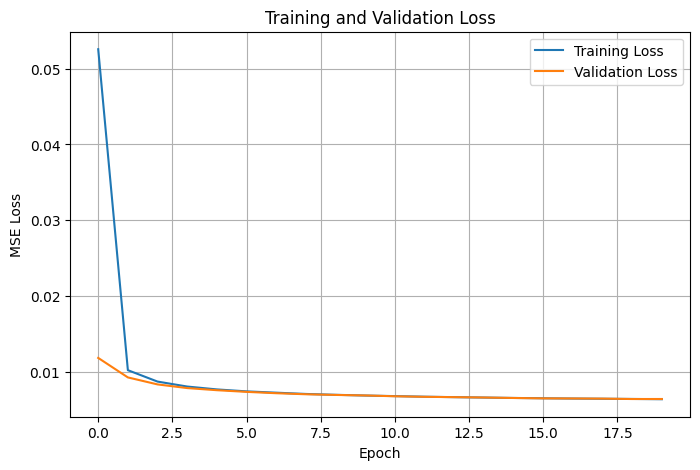

In [51]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    valid_losses,
    label="Validation Loss"
)

plt.title(
    "Training and Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.legend()
plt.grid(True)

plt.show()

## Step 13: Generating Denoised Outputs on the Test Dataset

In [52]:
model.eval()


test_images, test_labels = next(
    iter(test_loader)
)


test_images = test_images.to(device)

test_noisy_images = add_noise(
    test_images,
    noise_factor
)


with torch.no_grad():

    denoised_images = model(
        test_noisy_images
    )

print(
    "Denoised test images generated successfully."
)

Denoised test images generated successfully.


## Step 14: Visual Comparison of Original, Noisy, and Denoised Images

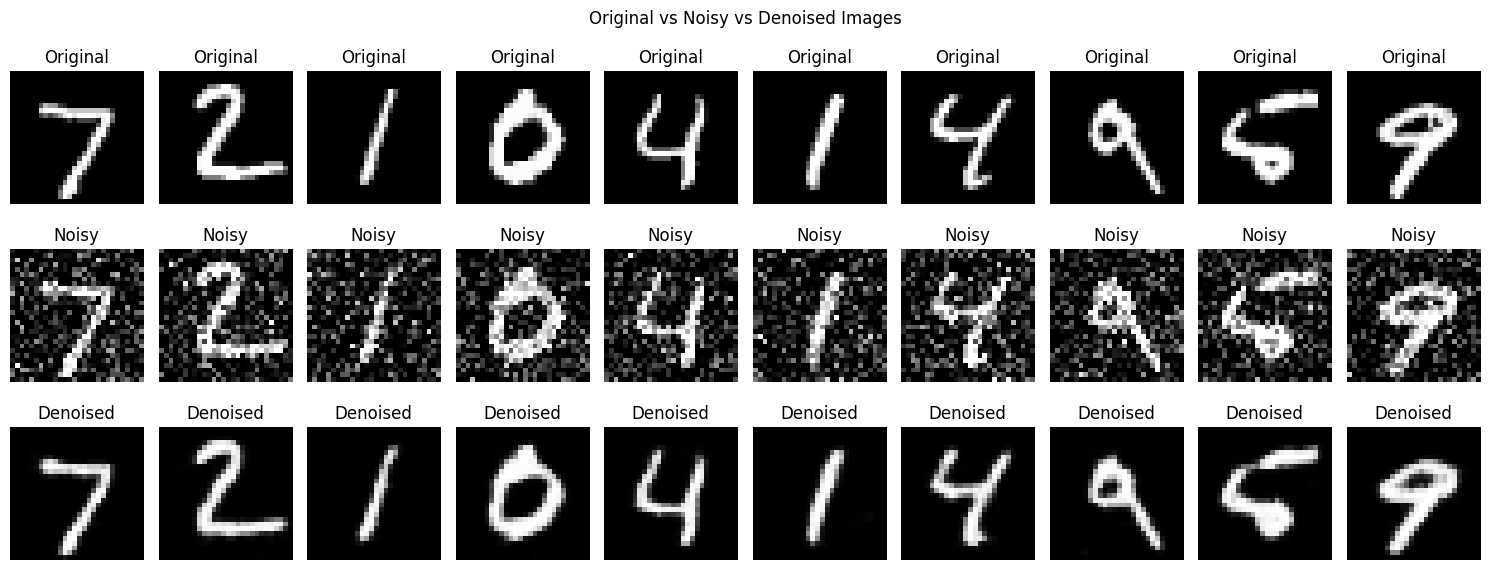

In [53]:
original_images = test_images.cpu()
noisy_images = test_noisy_images.cpu()
denoised_images = denoised_images.cpu()

n = 10

plt.figure(figsize=(15, 6))

for i in range(n):


    plt.subplot(3, n, i + 1)

    plt.imshow(
        original_images[i].squeeze(),
        cmap="gray"
    )

    plt.title("Original")
    plt.axis("off")


    plt.subplot(
        3,
        n,
        i + 1 + n
    )

    plt.imshow(
        noisy_images[i].squeeze(),
        cmap="gray"
    )

    plt.title("Noisy")
    plt.axis("off")


    plt.subplot(
        3,
        n,
        i + 1 + (2 * n)
    )

    plt.imshow(
        denoised_images[i].squeeze(),
        cmap="gray"
    )

    plt.title("Denoised")
    plt.axis("off")

plt.suptitle(
    "Original vs Noisy vs Denoised Images"
)

plt.tight_layout()
plt.show()

## Step 15: Evaluating Denoising Performance Using MSE


In [54]:
original_np = original_images.numpy()
noisy_np = noisy_images.numpy()
denoised_np = denoised_images.numpy()


original_flat = original_np.reshape(
    original_np.shape[0],
    -1
)

noisy_flat = noisy_np.reshape(
    noisy_np.shape[0],
    -1
)

denoised_flat = denoised_np.reshape(
    denoised_np.shape[0],
    -1
)


noisy_mse = mean_squared_error(
    original_flat,
    noisy_flat
)

denoised_mse = mean_squared_error(
    original_flat,
    denoised_flat
)

print(
    "MSE between Original and Noisy Images:",
    noisy_mse
)

print(
    "MSE between Original and Denoised Images:",
    denoised_mse
)

MSE between Original and Noisy Images: 0.04619314894080162
MSE between Original and Denoised Images: 0.00596363190561533


## Step 16: Calculating Denoising Improvement

In [55]:
if denoised_mse < noisy_mse:

    improvement = (
        (noisy_mse - denoised_mse)
        / noisy_mse
    ) * 100

    print(
        f"Denoising improved the MSE by "
        f"{improvement:.2f}%."
    )

else:

    print(
        "The denoising model did not improve "
        "the MSE compared to the noisy images."
    )

Denoising improved the MSE by 87.09%.


## Step 17: Visualizing MSE Comparison

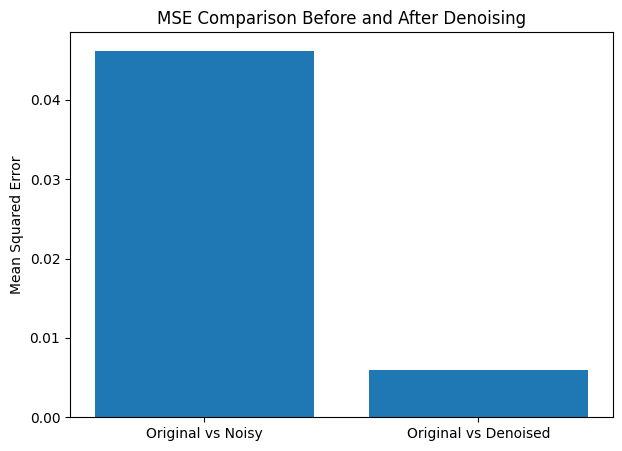

In [56]:
plt.figure(figsize=(7, 5))

plt.bar(
    [
        "Original vs Noisy",
        "Original vs Denoised"
    ],
    [
        noisy_mse,
        denoised_mse
    ]
)

plt.title(
    "MSE Comparison Before and After Denoising"
)

plt.ylabel("Mean Squared Error")

plt.show()

# Analysis and Observations

The MNIST dataset was successfully loaded and preprocessed using PyTorch. The images were converted into tensors, with pixel values normalized between 0 and 1.

Artificial Gaussian noise was introduced using a noise factor of 0.3. The noisy images were used as inputs to the denoising autoencoder, while the original clean images were used as target outputs.

A Convolutional Denoising Autoencoder was implemented using an encoder-decoder architecture. The encoder compressed the input images into a lower-dimensional representation, while the decoder reconstructed the clean images.

The model was trained using Mean Squared Error (MSE) as the reconstruction loss and Adam as the optimizer.

The visual comparison of the original, noisy, and denoised images shows that the model learned to reduce artificial noise while preserving the overall structure of handwritten digits.

The MSE between the original and noisy images was compared with the MSE between the original and denoised images. A lower MSE for the denoised images indicates that the model successfully reduced the noise.

The noise-level experiment showed that increasing the noise factor generally increased the MSE of the noisy images. Higher noise levels made the denoising task more challenging because more information was corrupted.

One challenge was selecting an appropriate noise factor. If the noise level is too low, the denoising task becomes relatively easy, while excessive noise can make it difficult for the model to reconstruct the original digit accurately.

Overall, the experiment demonstrated that convolutional autoencoders can learn useful image representations and perform image restoration tasks such as noise removal.

## Conclusion

In this project, I developed and trained a Convolutional Denoising Autoencoder using the MNIST handwritten digit dataset.

The model was trained using noisy images as input and clean images as target outputs. The encoder learned to extract meaningful features from noisy images, while the decoder reconstructed cleaner versions of the original images.

The denoising performance was evaluated using visual comparisons and Mean Squared Error (MSE). The results showed that the autoencoder was able to reduce artificial Gaussian noise while preserving the basic structure of handwritten digits.

The project provided practical experience in data preprocessing, artificial noise generation, convolutional neural networks, encoder-decoder architectures, model training, image reconstruction, and quantitative model evaluation.

As an additional experiment, different noise levels were tested to understand how increasing noise affects the denoising performance of the model.